# DAI Mission — Proposal
**Data & AI in Economics | TU Dortmund**

This notebook is our team's mission proposal. Once approved, we will extend this same notebook into our final deliverable.

> **Team size:** 3 students  
> **Deliverable:** This Jupyter Notebook (proposal → final submission in one file)


## 1. Team

| Role | Name | Student ID |
|------|------|------------|
| Lead |Vritika Kamra | |
| Member |Tom Skirde | |
| Member | Shantanu Modhave | |


## 2. Mission Title & Research Question

**Title:** Payment Trajectories and Causal Delinquency: Predicting Credit Card Default in Taiwan

**Research question:**  
Do earlier months of payment delinquency causally increase the probability of credit default beyond what the most recent payment behaviour already explains and can we identify distinct **repayment trajectory types** that serve as meaningful risk archetypes?

**Why it matters:**  
Credit card issuers must decide whether a borrower will default before it happens. Payment history is highly predictive, but correlation alone does not justify intervention (e.g. early collection calls or limit reductions). From a risk-management perspective, issuers need to know both which repayment patterns define high-risk customer types (unsupervised) and **whether recent delinquency causally raises default probability** after controlling for demographics and credit limit (causal inference). Our mission builds on the prior work of Yeh and Lien (2009) by adopting a more modern approach and incorporating additional methods, such as causal and trajectory-based reasoning thereby offering further insights.

Unsupervised clustering on **pre-treatment** payment status vectors (PAY_2–PAY_6, April–August) reveals **repayment trajectory archetypes** → causal inference (DoWhy) estimates whether **recent delinquency (PAY_0 / September)** raises default risk after backdoor adjustment on demographics, credit limit, and historical payment behaviour → supervised learning predicts default from full history, with **SHAP** showing which months matter most. We then **synthesise**: cluster labels are added as a feature to test whether archetypes add predictive signal; SHAP importance is compared to the causal ATE to assess convergent or divergent evidence.


## 3. Data

**Source(s):**  
UCI Machine Learning Repository — [Default of Credit Card Clients](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients) (Yeh, 2009)  
Licence: CC BY 4.0. Original paper: Yeh & Lien, *Expert Systems with Applications*, 2009.

**Unit of observation:** One credit card client-month record (30,000 rows, 23 features + 1 target)

**Key variables:**

| Variable | UCI code | Type | Role | Description |
|----------|----------|------|------|-------------|
| ID | — | integer | ID (excluded) | Client identifier — not used in modelling |
| LIMIT_BAL | X1 | numeric  | feature / confounder | Total credit limit (individual + supplementary) |
| SEX | X2 | categorical | feature / confounder | Gender (1 = male, 2 = female) |
| EDUCATION | X3 | categorical | feature / confounder | Education level (1 = grad school … 4 = others) |
| MARRIAGE | X4 | categorical | feature / confounder | Marital status (1 = married, 2 = single, 3 = others) |
| AGE | X5 | numeric (years) | feature / confounder | Client age |
| PAY_0 | X6 | ordinal | feature / treatment | Repayment status, Sep 2005 (−1 = on time 1–9 = months delayed) |
| PAY_2 | X7 | ordinal | feature / confounder | Repayment status, Aug 2005 |
| PAY_3 | X8 | ordinal | feature / confounder | Repayment status, Jul 2005 |
| PAY_4 | X9 | ordinal | feature / confounder | Repayment status, Jun 2005 |
| PAY_5 | X10 | ordinal | feature / confounder | Repayment status, May 2005 |
| PAY_6 | X11 | ordinal | feature / confounder | Repayment status, Apr 2005 |
| BILL_AMT1–6 | X12–X17 | numeric | feature / confounder | Bill statement amounts (Sep–Apr 2005) |
| PAY_AMT1–6 | X18–X23 | numeric | feature / confounder | Previous payment amounts (Sep–Apr 2005) |
| default | Y | binary | **target** | Default payment next month (0 = no, 1 = yes) ~22% default rate |

**Potential data quality issues:**  
Class imbalance (approximately 78% non-default, 22% default) makes accuracy misleading, we will use AUC-ROC.
EDUCATION contains miscoded values (0, 5, 6) and MARRIAGE (0) in some rows of the dataset.
The dataset is from Taiwan and was collected in the year 2005 therefore the findings may not hold across different time periods or locations.
Observational cross-section: no randomised intervention on delinquency, causal claims rely on the backdoor assumption. 

**Overview of key variables in the credit card default dataset, including repayment status, demographics, financial metrics, and default outcomes.**

In [2]:
# Data loading & first inspection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_STATE = 42

#Same as in the Dataset 
COL_NAMES = [
    "ID", "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    "default",
]

DATA_PATH = sorted(Path("data").glob("*.xls"))[0]
df = pd.read_excel(DATA_PATH, header=1)
df.columns = COL_NAMES

print(f"Loaded {DATA_PATH.name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("Missing values:", int(df.isnull().sum().sum()), "| Duplicate IDs:", int(df['ID'].duplicated().sum()))
print("PAY_0 codes present:", sorted(int(v) for v in df['PAY_0'].unique()))
print("Default rate:", round(df['default'].mean(), 4))
df.head(5)


Loaded default of credit card clients 2.xls: 30,000 rows x 25 columns
Missing values: 0 | Duplicate IDs: 0
PAY_0 codes present: [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
Default rate: 0.2212


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Description of the numeric data

**Summary statistics for continuous financial variables including credit limits, ages, bill amounts, and payment amounts.**

In [3]:
df[["LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]].describe()

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,9.217904,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,21.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,34.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,41.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,79.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


### Description of the categorical and binary data (Confounders)

**Distribution visualization of demographic characteristics and default status among credit card clients.**

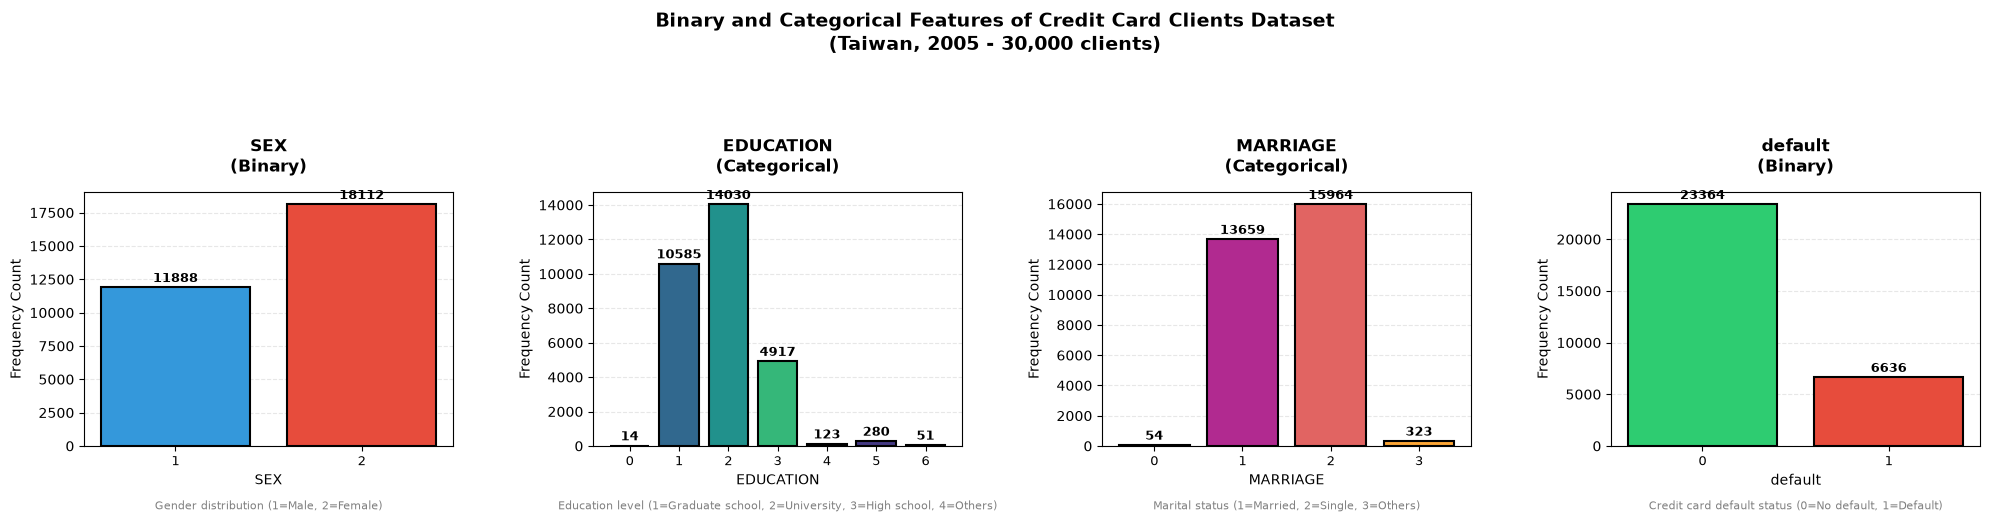

In [4]:
def plot_binary_and_categorical(input, titel):
    fig,axes=plt.subplots(1,4,figsize=(20,5))
    colors={'EDUCATION':sns.color_palette("viridis",5),'MARRIAGE':sns.color_palette("plasma",4),'SEX':['#3498db','#e74c3c'],'default':['#2ecc71','#e74c3c']}
    descriptions={'SEX':'Gender distribution (1=Male, 2=Female)','EDUCATION':'Education level (1=Graduate school, 2=University, 3=High school, 4=Others)','MARRIAGE':'Marital status (1=Married, 2=Single, 3=Others)','default':'Credit card default status (0=No default, 1=Default)'}
    for i,(col,ax)in enumerate(zip(["SEX","EDUCATION","MARRIAGE","default"],axes)):
        counts=input[col].value_counts().sort_index()
        bars=ax.bar(range(len(counts)),counts.values,color=colors[col],edgecolor='black',linewidth=1.5)
        for b,c in zip(bars,counts.values):ax.text(b.get_x()+b.get_width()/2.,b.get_height()+max(counts.values)*0.01,f'{c}',ha='center',va='bottom',fontsize=9,fontweight='bold')
        ax.set_title(f'{col}\n({"Binary" if col in ["SEX","default"] else "Categorical"})',fontweight='bold',fontsize=12,pad=15)
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(counts.index,fontsize=9)
        ax.set_ylabel('Frequency Count',fontsize=10)
        ax.set_xlabel(col,fontsize=10)
        ax.grid(axis='y',alpha=0.3,linestyle='--')
        ax.set_axisbelow(True)
        ax.text(0.5,-0.25,descriptions[col],transform=ax.transAxes,ha='center',fontsize=8,color='gray')
    plt.suptitle(titel,fontsize=14,fontweight='bold',y=1.1)
    plt.tight_layout()
    plt.show()
plot_binary_and_categorical(df, 'Binary and Categorical Features of Credit Card Clients Dataset\n(Taiwan, 2005 - 30,000 clients)')

### Description ordinal data

**Payment status distributions across six months showing repayment patterns from September to April.**

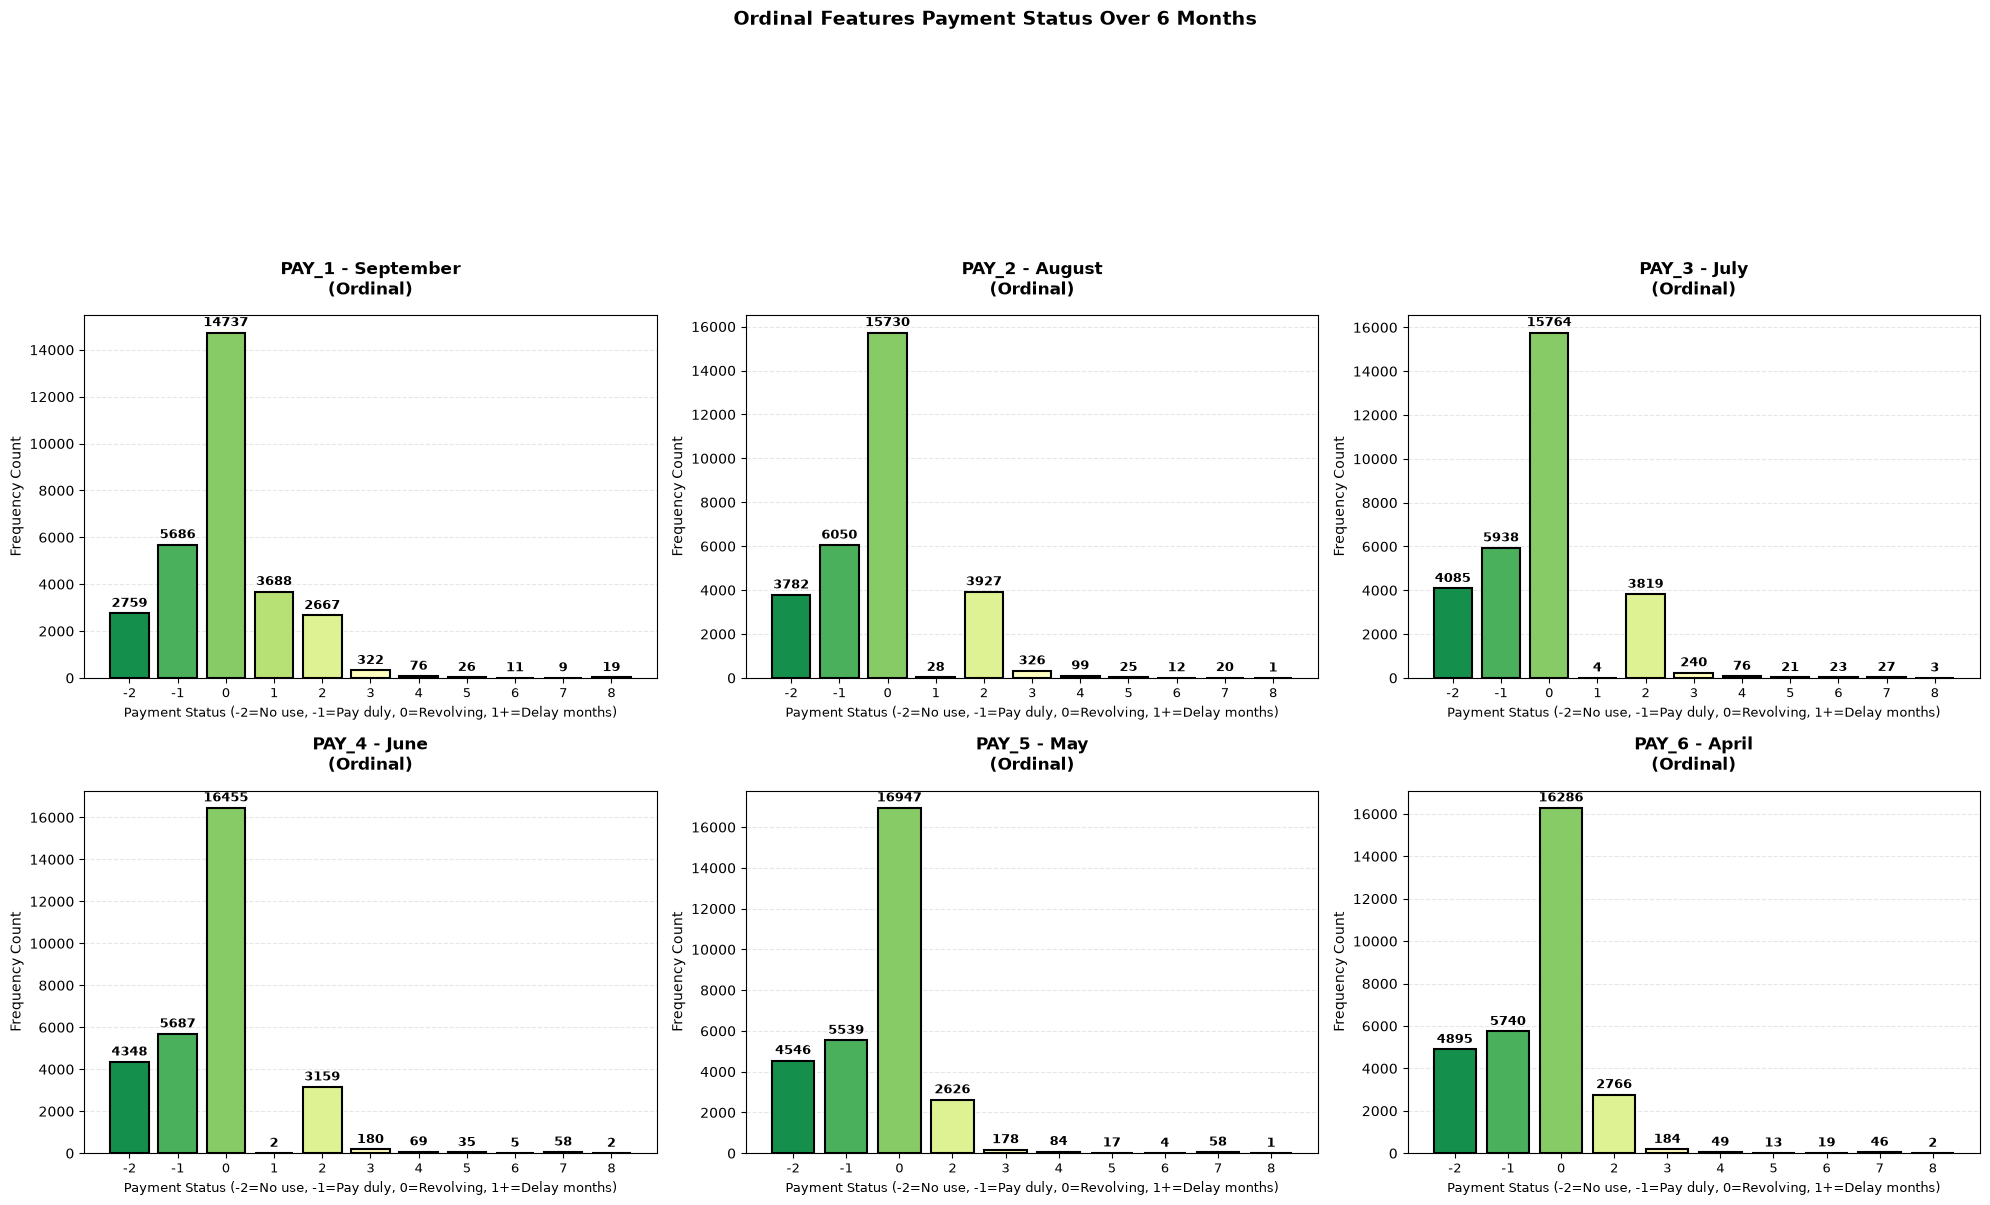

In [5]:
df_temp = pd.read_excel(DATA_PATH, header=1).rename(columns={'PAY_0': 'PAY_1'})
pay_cols, months = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'], ['September', 'August', 'July', 'June', 'May', 'April']
colors_pay = sns.color_palette("RdYlGn_r", 11)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for i, (col, month, ax) in enumerate(zip(pay_cols, months, axes.flatten())):
    counts = df_temp[col].value_counts().sort_index()
    bar_colors = [colors_pay[min(val + 2, 10)] for val in counts.index]
    bars = ax.bar(range(len(counts)), counts.values, color=bar_colors, edgecolor='black', linewidth=1.5)
    [ax.text(b.get_x() + b.get_width()/2., b.get_height() + max(counts.values)*0.01, f'{c}', ha='center', va='bottom', fontsize=9, fontweight='bold') for b, c in zip(bars, counts.values)]
    ax.set_title(f'PAY_{i+1} - {month}\n(Ordinal)', fontweight='bold', fontsize=12, pad=15)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, fontsize=9)
    ax.set_ylabel('Frequency Count', fontsize=10)
    ax.set_xlabel('Payment Status (-2=No use, -1=Pay duly, 0=Revolving, 1+=Delay months)', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

plt.suptitle('Ordinal Features Payment Status Over 6 Months', fontsize=14, fontweight='bold', y=1.2)
plt.tight_layout()
plt.show()

### Data cleaning

**Dataset refinement: recoding out-of-codebook EDUCATION/MARRIAGE values (rather than dropping rows) while preserving the class distribution.**

The repayment-status codes `-2` (no consumption) and `0` (revolving credit) are *not* errors — together with `-1` (paid in full) they are valid non-delinquent states and are retained as the low end of the ordinal PAY scale (`1…9` = months delayed).

Before:  EDUCATION {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
         MARRIAGE  {0: 54, 1: 13659, 2: 15964, 3: 323}
After:   EDUCATION {1: 10585, 2: 14030, 3: 4917, 4: 468}
         MARRIAGE  {1: 13659, 2: 15964, 3: 377}


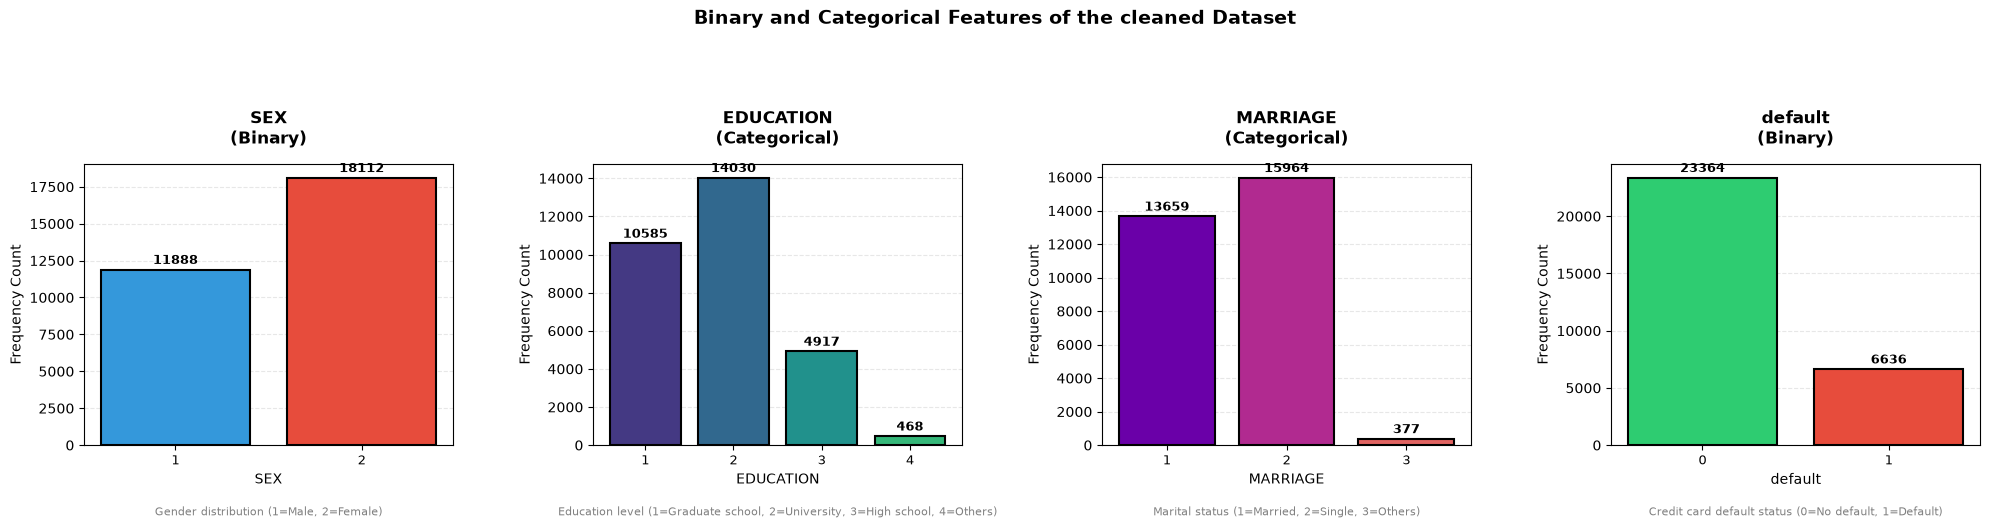

In [6]:
# Recode out-of-codebook anomalies (work plan: "recode EDUCATION anomalies").
# Recode rather than drop -> preserves sample size and the ~22% class balance.
# EDUCATION: fold undocumented {0, 5, 6} into 4 ("others"); MARRIAGE: fold {0} into 3 ("others").
print("Before:  EDUCATION", df['EDUCATION'].value_counts().sort_index().to_dict())
print("         MARRIAGE ", df['MARRIAGE'].value_counts().sort_index().to_dict())

df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

print("After:   EDUCATION", df['EDUCATION'].value_counts().sort_index().to_dict())
print("         MARRIAGE ", df['MARRIAGE'].value_counts().sort_index().to_dict())
plot_binary_and_categorical(df, 'Binary and Categorical Features of the cleaned Dataset')

### Train/test split

Stratified 80/20 split on `default` (`ID` excluded). The same split is reused by the supervised block so evaluation never sees training rows.

In [7]:
from sklearn.model_selection import train_test_split

TARGET = "default"
feature_cols = [c for c in df.columns if c not in ("ID", TARGET)]
X = df[feature_cols].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Features: {len(feature_cols)} | Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Default rate -- full: {y.mean():.4f} | train: {y_train.mean():.4f} | test: {y_test.mean():.4f}")

Features: 23 | Train: 24,000 rows | Test: 6,000 rows
Default rate -- full: 0.2212 | train: 0.2212 | test: 0.2212


## 4. Planned Methods


Your mission **must** apply at least one technique from **each** of the three blocks below. Tick the ones you plan to use and briefly justify the choice.

### 4a. Causal Inference
- [x] Causal graph / DAG (DoWhy)
- [x] Backdoor adjustment
- [ ] Instrumental variable
- [x] Propensity score weighting / stratification
- [ ] Other: ___

*Justification:* We hypothesise that recent delinquency (PAY_0 / September) affects default, but demographics, credit limit (LIMIT_BAL, AGE, SEX, EDUCATION, MARRIAGE), and **historical payment behaviour (PAY_2–PAY_6)** confound both payment behaviour and default, they open backdoor paths that must be blocked. Earlier months (PAY_2–PAY_6) temporally precede September and therefore act as **confounders**. We draw an explicit DAG, and estimate the ATE with DoWhy backdoor propensity score weighting, adjusting on common causes. Refutation: `placebo_treatment_refuter` if the effect collapses to ~0, the original estimate is less likely to be noise.

**Planned DAG (verbal):**  
`PAY_2–PAY_6 (Apr–Aug)` and `LIMIT_BAL, AGE, SEX, EDUCATION, MARRIAGE` → `PAY_0 (Sep)` → `default (Oct/Nov)`, with demographics and historical payments also → `default` directly.

### 4b. Supervised Learning
- [ ] Linear / Ridge / Lasso regression
- [x] Logistic regression
- [ ] k-Nearest Neighbors
- [ ] Support Vector Machine
- [x] Decision Tree / Random Forest
- [ ] Neural network (regression or classification)
- [x] Other: SHAP feature importance; optional cluster label as added feature

*Justification:* Prediction task: given full payment history and demographics, how well can we predict next-month default? Logistic regression is the interpretable baseline, Random Forest captures nonlinear interactions among bill/payment amounts. Stratified 5-fold CV with AUC-ROC (appropriate for ~22% default rate). SHAP on the Random Forest identifies which month's payment status drives predictions, compared to the causal ATE on PAY_0 in synthesis. We will also test whether adding unsupervised cluster labels improves AUC.

### 4c. Unsupervised Learning / Generative Models
- [x] K-Means clustering
- [x] Hierarchical clustering
- [ ] Variational autoencoder
- [ ] GAN
- [ ] Other: ___

*Justification:* Cluster only on the **five pre-treatment** payment-status columns (PAY_2–PAY_6, April–August) **to discover repayment trajectory archetypes** (e.g. consistently on time, slowly deteriorating, chronically late, recovery). We **exclude PAY_0 (September treatment)** from clustering to avoid data leakage and circularity, cluster archetypes must be defined independently of the treatment variable. Deliberately exclude demographics and amounts so clusters reflect behaviour, not background attributes. Select k via silhouette score (k = 2…8), validate with an agglomerative dendrogram. Report default rate per cluster and visualise cluster centroids as a heatmap (rows = clusters, columns = months).


## 5. Evaluation Strategy

*How will we know if our mission succeeded?*

| Block | Metrics | Validation / benchmarks |
|-------|---------|-------------------------|
| **Unsupervised** | Silhouette score (k = 2…8), default rate per cluster | Heatmap of cluster centroids, human-readable archetype names (e.g. "chronically late", "recovery"), hierarchical dendrogram |
| **Causal** | ATE of binarised PAY_0 on `default`, with CI | DoWhy **placebo treatment refuter** (permute), interpret collapse of effect as robustness evidence |
| **Supervised** | AUC-ROC (mean ± std over 5 folds) | **Logistic regression baseline** vs **Random Forest**, explain why AUC beats accuracy under 22% default rate |
| **Explainability** | SHAP mean \|value\| by feature | Compare top SHAP month (likely PAY_0) to causal ATE direction and magnitude |
| **Synthesis** | ΔAUC when adding `cluster` to Random Forest | If ΔAUC > 0, archetypes add signal,if ≈ 0, model already encodes trajectories |

**Success criteria:**
- Clusters show materially different default rates and interpretable repayment trajectories.
- Causal ATE is estimated, refutation run, and result interpreted in plain language.
- Random Forest beats logistic baseline on AUC, SHAP identifies which payment months matter most.
- Section 8 connects all three blocks and directly answers the research question, including limitations (backdoor assumption untestable, cross-sectional data).


## 6. Work Plan

| Step | Owner | Description |
|------|-------|-------------|
| 1 | Shantanu| Load UCI dataset, rename columns, inspect PAY_0–PAY_6 codes (handle 0, −2), recode EDUCATION anomalies, train/test split |
| 2 | Vritika | EDA: default rate, payment status distributions, bill/payment amount summaries |
| 3 | All | **Unsupervised block:** standardise PAY_2–PAY_6 (pre-treatment only), K-Means + silhouette, dendrogram, cluster heatmap, default rate per archetype |
| 4 | All | **Causal block:** DAG diagram, binarise PAY_0, DoWhy backdoor propensity weighting, placebo refutation |
| 5 | All | **Supervised block:** logistic regression vs Random Forest, stratified 5-fold AUC, SHAP summary plot, retrain RF with `cluster` feature |
| 6 | Tom | Synthesis write-up (Sections 7–8): connect SHAP ↔ causal ATE ↔ clusters, limitations, notebook polish |


---
### 7a. Unsupervised / Generative

In [9]:
# Unsupervised / generative analysis (K-Means, hierarchical clustering, silhouette)

### 7b. Causal Inference

In [10]:
# Causal: DoWhy — treatment=PAY_0 (binarised), outcome=default,
# common_causes=[LIMIT_BAL, AGE, SEX, EDUCATION, MARRIAGE]
# method=backdoor.propensity_score_weighting; refute=placebo_treatment_refuter

### 7c. Supervised Learning

** 1 — Feature pipeline, baseline model & imbalance-aware evaluation.**

Task: predict next-month `default` from demographics, credit limit and the full
payment history. We start with an interpretable **Logistic Regression** baseline.

Because the data are imbalanced (~22% default), accuracy is misleading, so we
evaluate with three complementary metrics via **stratified 5-fold CV**:
- **ROC-AUC** — ranking quality across all thresholds;
- **PR-AUC** (average precision) — focuses on the minority (default) class; the
  no-skill reference equals the default prevalence (~0.22);
- **F1** — balances precision and recall at the 0.5 threshold.

Our first imbalance strategy is `class_weight="balanced"`. Phase 2 adds the Random
Forest and a SMOTE ablation; Phase 3 adds SHAP and the cluster-feature synthesis.

In [8]:
# === Supervised Block — Phase 1: preprocessing & feature roles ===
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
)

# Feature groups (uses feature_cols and the X_train/X_test split from Section 3)
nominal_cols = ["SEX", "EDUCATION", "MARRIAGE"]          # one-hot encode
ordinal_pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
# Derive the feature list from df so this cell does not depend on the split-cell variable
feature_cols = [c for c in df.columns if c not in ("ID", "default")]
numeric_cols = [c for c in feature_cols if c not in nominal_cols + ordinal_pay_cols]

print("nominal :", nominal_cols)
print("ordinal :", ordinal_pay_cols)
print("numeric :", numeric_cols)

# Shared preprocessor: scale numeric + PAY ordinals (helps the linear model),
# one-hot the nominal categoricals. Built fresh per pipeline to avoid leakage.
def make_preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), numeric_cols + ordinal_pay_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), nominal_cols),
    ])

nominal : ['SEX', 'EDUCATION', 'MARRIAGE']
ordinal : ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
numeric : ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [9]:
# === Phase 1: reusable imbalance-aware evaluation harness ===
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1"}

def cv_report(model, name, X=X_train, y=y_train):
    """Stratified 5-fold CV reporting ROC-AUC, PR-AUC and F1 (mean ± std)."""
    res = cross_validate(model, X, y, cv=CV, scoring=SCORING, n_jobs=-1)
    means = {m: res[f"test_{m}"].mean() for m in SCORING}
    print(f"{name} — 5-fold CV:")
    for m in SCORING:
        print(f"   {m:>7}: {res[f'test_{m}'].mean():.3f} ± {res[f'test_{m}'].std():.3f}")
    return means

def test_metrics(model, name, threshold=0.5):
    """Fit on the training split and report metrics on the held-out test set."""
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    out = {
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "f1": f1_score(y_test, pred),
    }
    print(f"{name} — held-out test: "
          f"ROC-AUC={out['roc_auc']:.3f} | PR-AUC={out['pr_auc']:.3f} | F1={out['f1']:.3f}")
    return model, proba, out

In [10]:
# === Phase 1: Logistic Regression baseline (imbalance strategy = class_weight='balanced') ===
logreg = Pipeline([
    ("prep", make_preprocessor()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                               random_state=RANDOM_STATE)),
])

logreg_cv = cv_report(logreg, "LogReg (balanced)")
logreg, logreg_proba, logreg_test = test_metrics(logreg, "LogReg (balanced)")

# Persist results so Phase 2/3 can compare against this baseline
results = {"LogReg (balanced)": {"cv": logreg_cv, "test": logreg_test}}

no_skill_pr = y_train.mean()
print(f"\nNo-skill PR-AUC baseline (default prevalence) = {no_skill_pr:.3f}")

LogReg (balanced) — 5-fold CV:
   roc_auc: 0.728 ± 0.011
    pr_auc: 0.505 ± 0.013
        f1: 0.481 ± 0.012
LogReg (balanced) — held-out test: ROC-AUC=0.710 | PR-AUC=0.491 | F1=0.465

No-skill PR-AUC baseline (default prevalence) = 0.221


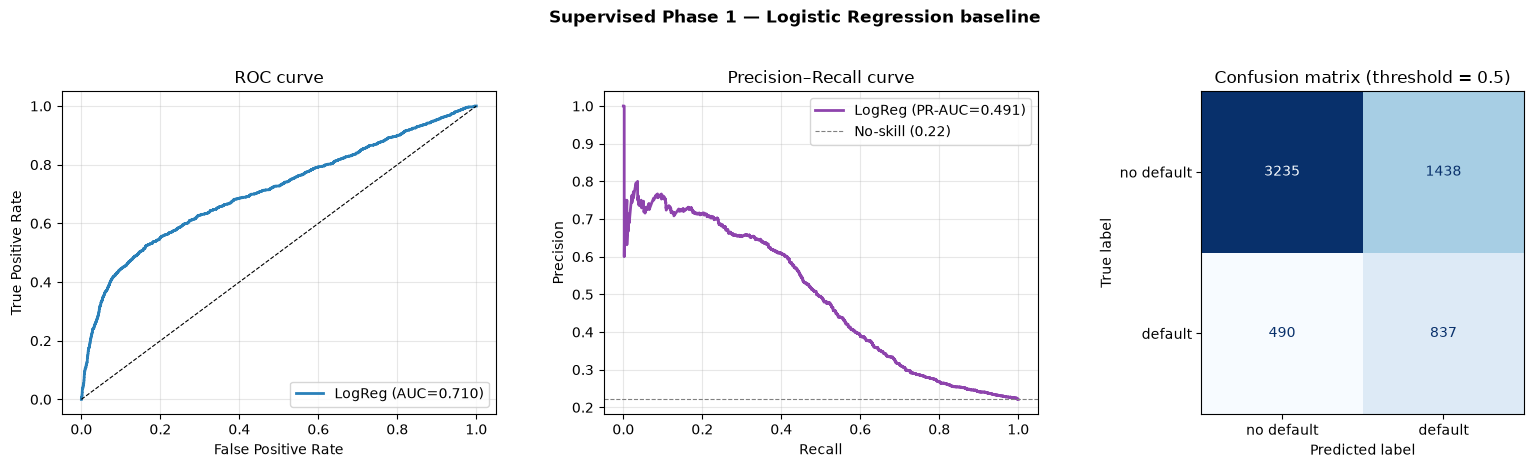

In [11]:
# === Phase 1: baseline diagnostics — ROC, Precision–Recall, confusion matrix ===
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

fpr, tpr, _ = roc_curve(y_test, logreg_proba)
axes[0].plot(fpr, tpr, color="#2980b9", lw=2,
             label=f"LogReg (AUC={logreg_test['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC curve")
axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, logreg_proba)
axes[1].plot(rec, prec, color="#8e44ad", lw=2,
             label=f"LogReg (PR-AUC={logreg_test['pr_auc']:.3f})")
axes[1].axhline(no_skill_pr, color="gray", ls="--", lw=0.8,
                label=f"No-skill ({no_skill_pr:.2f})")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision–Recall curve")
axes[1].legend(loc="upper right"); axes[1].grid(alpha=0.3)

cm = confusion_matrix(y_test, (logreg_proba >= 0.5).astype(int))
ConfusionMatrixDisplay(cm, display_labels=["no default", "default"]).plot(
    ax=axes[2], cmap="Blues", colorbar=False)
axes[2].set_title("Confusion matrix (threshold = 0.5)")

plt.suptitle("Supervised Phase 1 — Logistic Regression baseline", y=1.03, fontweight="bold")
plt.tight_layout(); plt.show()

**1 takeaways.**
- The Logistic Regression baseline already separates defaulters well above chance on
  ROC-AUC, and its PR-AUC sits clearly above the no-skill prevalence line (~0.22) —
  confirming genuine signal for the minority class, which a plain accuracy score
  would have hidden.
- `class_weight="balanced"` trades a little precision for substantially better
  recall of defaulters (visible in the confusion matrix), which is the operationally
  relevant error for a credit issuer.
- These three metrics (ROC-AUC, PR-AUC, F1)

## 8. Discussion & Conclusion *(complete for final submission)*

*Synthesise findings across all three method blocks. What does each lens reveal that the others miss? What are the limitations of your analysis?*
